In [1]:
#Creating make moons
from sklearn.datasets import make_moons
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import time
#Using Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

In [26]:
X, y = make_moons(n_samples=100000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

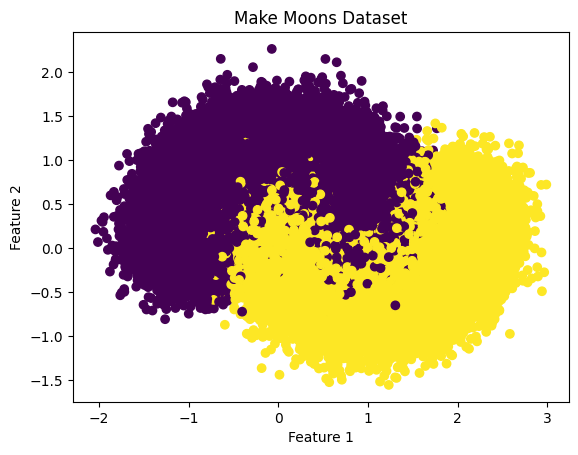

In [27]:
#Plotting the data
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title("Make Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [28]:
#Using Gradient Boosting Classifier
model = GradientBoostingClassifier()
start = time.time()
model.fit(X_train, y_train)
end = time.time()
training_time = end - start
print("Training time of Gradient Boosting Classifier:", training_time)

Training time of Gradient Boosting Classifier: 4.696638345718384


In [29]:
#Predicting and evaluating Gradient Boosting Classifier
y_pred_gb = model.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Classifier Accuracy:", accuracy_gb)

Gradient Boosting Classifier Accuracy: 0.9113


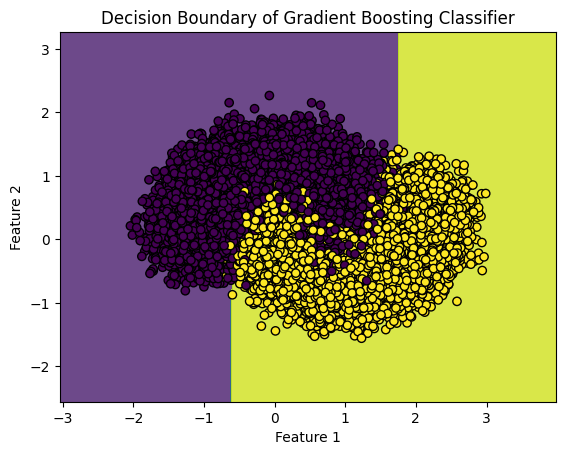

In [30]:
#Drawing decision boundary
import numpy as np
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
plt.title("Decision Boundary of Gradient Boosting Classifier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()  

In [31]:
#Trying XGBClassifier
model1 = XGBClassifier(n_jobs=4)
start1 = time.time()
model1.fit(X_train, y_train)
end1 = time.time()
fit_time = end1 - start1
print("Training time of XGBClassifier:", fit_time)

Training time of XGBClassifier: 0.16063380241394043


In [32]:
#Evaluating XGBClassifier
y_pred_xgb = model1.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("XGBClassifier Accuracy:", accuracy_xgb)

XGBClassifier Accuracy: 0.9123


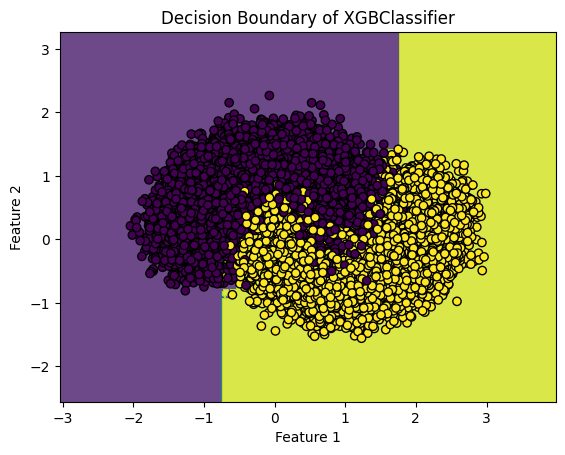

In [33]:
#Drawing the decision boundary for XGBClassifier
Z1 = model1.predict(np.c_[xx.ravel(), yy.ravel()])
Z1 = Z1.reshape(xx.shape)
plt.contourf(xx, yy, Z1, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
plt.title("Decision Boundary of XGBClassifier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [34]:
#Boost in training time but with accuracy trade-off
percentage_increase = training_time / fit_time * 100
print(f"XGBClassifier is {percentage_increase:.2f}% faster than Gradient Boosting Classifier.")

accuracy_drop = accuracy_gb - accuracy_xgb
print(f"XGBClassifier has an accuracy drop of {accuracy_drop:.4f} compared to Gradient Boosting Classifier.")

XGBClassifier is 2923.82% faster than Gradient Boosting Classifier.
XGBClassifier has an accuracy drop of -0.0010 compared to Gradient Boosting Classifier.
